# STABL Baseline Study Group + P/NP Analysis

This notebook reuses the cache-first AURORA baseline workflow and evaluates the crossed baseline labels `EG_P`, `EG_NP`, `TU_P`, `TU_NP`, `GA_P`, and `GA_NP`. It also loads within-study P-vs-NP comparisons for `EG`, `TU`, and `GA` from SLURM-produced caches.

Heavy STABL fitting is disabled by default. Run the paired SLURM scripts under `scratch/slurm/` to populate caches, then rerun this notebook to inspect results.

## Runtime Controls

The helper below resolves paths from the repository root, so the notebook can be opened from either the repo root or `scratch/` and still read the canonical cache/output directories.

In [1]:
# Runtime controls -------------------------------------------------------------
helper_candidates <- c(
  file.path("scratch", "scripts", "stablr_baseline_group_protection_helpers.R"),
  file.path("..", "scratch", "scripts", "stablr_baseline_group_protection_helpers.R"),
  "/exports/para-lipg-hpc/mdmanurung/stablr/scratch/scripts/stablr_baseline_group_protection_helpers.R"
)
helper_path <- helper_candidates[file.exists(helper_candidates)][1L]
if (is.na(helper_path)) {
  stop("Could not locate stablr_baseline_group_protection_helpers.R", call. = FALSE)
}
source(helper_path)
setup_stablr_for_baseline()

config <- group_protection_config()
LOAD_CACHED_RESULTS <- TRUE
RUN_PREPROCESS_LOCALLY <- FALSE
RUN_MISSING_BRANCHES_LOCALLY <- FALSE
FORCE_RECOMPUTE <- FALSE

VIEW_NAMES <- names(baseline_default_paths())
JOINT_LEVELS <- config$joint_levels
STUDY_LEVELS <- config$study_levels
PROTECTION_LEVELS <- config$protection_levels

list(
  cache_dir = config$cache_dir,
  export_dir = config$export_dir,
  source_cache_dir = config$source_cache_dir,
  joint_levels = JOINT_LEVELS,
  study_levels = STUDY_LEVELS,
  view_count = length(VIEW_NAMES),
  load_cached_results = LOAD_CACHED_RESULTS,
  run_preprocess_locally = RUN_PREPROCESS_LOCALLY,
  run_missing_branches_locally = RUN_MISSING_BRANCHES_LOCALLY
)

Warning message:
“package ‘testthat’ was built under R version 4.5.2”
Warning message:
“package ‘dplyr’ was built under R version 4.5.2”
Warning message:
“package ‘tidyr’ was built under R version 4.5.2”
Warning message:
“package ‘ggplot2’ was built under R version 4.5.3”
Warning message:
“package ‘tibble’ was built under R version 4.5.2”
Warning message:
“package ‘readr’ was built under R version 4.5.2”
Warning message:
“package ‘forcats’ was built under R version 4.5.2”


$cache_dir
[1] "/exports/para-lipg-hpc/mdmanurung/stablr/scratch/cache/stablr_baseline_group_protection_test"

$export_dir
[1] "/exports/para-lipg-hpc/mdmanurung/stablr/scratch/outputs/stablr_baseline_group_protection_test"

$source_cache_dir
[1] "/exports/para-lipg-hpc/mdmanurung/stablr/scratch/cache/stablr_baseline_groups_test"

$joint_levels
[1] "EG_P"  "EG_NP" "TU_P"  "TU_NP" "GA_P"  "GA_NP"

$study_levels
[1] "EG" "TU" "GA"

$view_count
[1] 11

$load_cached_results
[1] TRUE

$run_preprocess_locally
[1] FALSE

$run_missing_branches_locally
[1] FALSE

## Baseline QC

The preprocessing cache derives `group_protection = paste(study_group, protection, sep = "_")` from the existing baseline study-group cache. Expected six-class counts are `EG_P=6`, `EG_NP=4`, `TU_P=9`, `TU_NP=3`, `GA_P=8`, and `GA_NP=8`.

In [2]:
# Load preprocessing cache -----------------------------------------------------
preprocess_cache_path <- file.path(config$cache_dir, "preprocess", "baseline_preprocessed.rds")

gp_data <- NULL
if (isTRUE(LOAD_CACHED_RESULTS) && !isTRUE(FORCE_RECOMPUTE) && file.exists(preprocess_cache_path)) {
  gp_data <- readRDS(preprocess_cache_path)
  message("Loaded group-protection preprocessing cache: ", preprocess_cache_path)
} else if (isTRUE(RUN_PREPROCESS_LOCALLY)) {
  gp_data <- preprocess_group_protection_views(config, force = FORCE_RECOMPUTE)
} else {
  message("Group-protection preprocessing cache is absent. Run `sbatch scratch/slurm/stablr_baseline_group_protection_preprocess.slurm` or set RUN_PREPROCESS_LOCALLY <- TRUE.")
}

if (!is.null(gp_data)) {
  baseline_class_qc <- gp_data$baseline_class_qc
  baseline_study_protection_qc <- gp_data$baseline_study_protection_qc
  baseline_view_qc <- gp_data$baseline_view_qc

  observed_counts <- stats::setNames(baseline_class_qc$n, as.character(baseline_class_qc$group_protection))
  missing_expected <- setdiff(names(config$expected_joint_counts), names(observed_counts))
  if (length(missing_expected) > 0L || any(observed_counts[names(config$expected_joint_counts)] != config$expected_joint_counts)) {
    warning("Observed six-class counts differ from the expected baseline counts.", call. = FALSE)
  }

  baseline_class_qc
  baseline_study_protection_qc
  baseline_view_qc
}

Loaded group-protection preprocessing cache: /exports/para-lipg-hpc/mdmanurung/stablr/scratch/cache/stablr_baseline_group_protection_test/preprocess/baseline_preprocessed.rds



view,n_samples,n_features,n_missing,frobenius_norm
<chr>,<int>,<int>,<int>,<dbl>
cytof_celltype,38,125,0,0.5692460
exvivo_celltype,38,40,0,0.5401055
exvivo_enzyme,38,98,0,0.5694408
6h_cyto_LPS,38,130,0,0.5570706
6h_cyto_ssRNA40,38,130,0,0.5843107
24h_cyto_iRBC,38,157,0,0.4690036
24h_cyto_SEB,38,165,0,0.5381928
24h_enzyme_iRBC,38,94,0,0.5260319
24h_enzyme_SEB,38,99,0,0.5374754


## Cache Readers

These readers consume branch-local RDS and CSV artifacts. If a cache is missing, the notebook reports the missing branch and continues.

In [3]:
# Cache readers ----------------------------------------------------------------
branch_cache_path <- function(branch, name) {
  file.path(config$cache_dir, branch, paste0(name, ".rds"))
}

branch_table_path <- function(branch, name) {
  file.path(config$export_dir, branch, "tables", paste0(name, ".csv"))
}

load_cached_rds <- function(branch, name) {
  path <- branch_cache_path(branch, name)
  if (!file.exists(path)) return(NULL)
  readRDS(path)
}

load_cached_table <- function(branch, name) {
  path <- branch_table_path(branch, name)
  if (!file.exists(path)) return(NULL)
  readr::read_csv(path, show_col_types = FALSE)
}

cached_branch_available <- function(branch, name = "stabl_fit_bundle") {
  file.exists(branch_cache_path(branch, name))
}

maybe_run_branch <- function(branch) {
  if (!isTRUE(RUN_MISSING_BRANCHES_LOCALLY)) return(invisible(FALSE))
  if (is.null(gp_data)) stop("Preprocessing data must be loaded before local branch execution.", call. = FALSE)
  run_group_protection_branch(branch, gp_data, config)
  merge_artifact_manifests(config)
  invisible(TRUE)
}

single_view_summary_from_cache <- function(scope, study = NULL) {
  purrr::map_dfr(VIEW_NAMES, function(view) {
    branch <- if (identical(scope, "joint")) {
      file.path("joint", "single_view", view)
    } else {
      file.path("within", study, "single_view", view)
    }
    table <- load_cached_table(branch, "feature_importance")
    if (is.null(table)) {
      maybe_run_branch(gsub("/", ":", branch))
      table <- load_cached_table(branch, "feature_importance")
    }
    if (is.null(table) || nrow(table) == 0L) {
      return(tibble::tibble())
    }
    table |>
      dplyr::summarise(
        comparison = dplyr::first(.data$comparison),
        view = view,
        n_features = dplyr::n(),
        n_selected = sum(.data$selected, na.rm = TRUE),
        max_stability = max(.data$stability_score, na.rm = TRUE),
        top_feature = .data$feature[which.max(.data$stability_score)],
        .groups = "drop"
      )
  })
}

load_top_features <- function(branch, n = 25L) {
  table <- load_cached_table(branch, "top_features")
  if (is.null(table)) return(tibble::tibble())
  table |> dplyr::slice_head(n = n)
}

load_late_fusion_bundle <- function(branch) {
  list(
    weights = load_cached_table(branch, "late_fusion_weights"),
    metrics = load_cached_table(branch, "late_fusion_metrics"),
    per_outcome_metrics = load_cached_table(branch, "late_fusion_per_outcome_metrics"),
    confusion = load_cached_table(branch, "late_fusion_confusion_matrix"),
    predictions = load_cached_table(branch, "late_fusion_train_predictions")
  )
}

## Joint Six-Class Models

These branches model all six crossed groups together. The target order is fixed as `EG_P`, `EG_NP`, `TU_P`, `TU_NP`, `GA_P`, `GA_NP`.

In [4]:
# Joint single-view summary ----------------------------------------------------
joint_single_view_summary <- single_view_summary_from_cache("joint")
if (nrow(joint_single_view_summary) == 0L) {
  message("No joint single-view caches found. Run `sbatch scratch/slurm/stablr_baseline_group_protection_branches.slurm` or a specific `joint:single_view:<view>` branch.")
}
joint_single_view_summary

comparison,view,n_features,n_selected,max_stability,top_feature
<chr>,<chr>,<int>,<int>,<dbl>,<chr>
joint_group_protection,cytof_celltype,125,19,1,clr_102
joint_group_protection,exvivo_celltype,40,22,1,clustFreqs_Bcells.c10
joint_group_protection,exvivo_enzyme,98,26,1,exvivo_Bcells.c15_Atypical_Tbet.CD11c._PC1
joint_group_protection,6h_cyto_LPS,130,20,1,LPS_Myeloids_c18_MonocytesHLADRlo_IL10
joint_group_protection,6h_cyto_ssRNA40,130,23,1,ssRNA40_Myeloids_c18_MonocytesHLADRlo_IL10
joint_group_protection,24h_cyto_iRBC,157,30,1,iRBC_CD4T_c40_tregs_FoxP3hi_AnyTH1
joint_group_protection,24h_cyto_SEB,165,10,1,SEB_CD4T_c25_tregs_IL10
joint_group_protection,24h_enzyme_iRBC,94,21,1,iRBC_CD4T_c12_cm_PC1
joint_group_protection,24h_enzyme_SEB,99,25,1,SEB_CD4T_c12_cm_PC1


In [5]:
# Joint early fusion -----------------------------------------------------------
joint_early_branch <- file.path("joint", "early_fusion")
if (!cached_branch_available(joint_early_branch)) {
  maybe_run_branch("joint:early_fusion")
}
joint_early_bundle <- load_cached_rds(joint_early_branch, "stabl_fit_bundle")
joint_early_top_features <- load_top_features(joint_early_branch, n = 50L)

list(
  early_fusion_loaded = !is.null(joint_early_bundle),
  selected_features = if (!is.null(joint_early_bundle)) get_feature_names_out(joint_early_bundle$fit) else character(),
  top_features = joint_early_top_features
)

comparison,outcome_level,feature,stability_score,selected
<chr>,<chr>,<chr>,<dbl>,<lgl>
joint_group_protection,global,3d_cyto__X3D_CD4T_c27_CD161._Th2,1.000,TRUE
joint_group_protection,global,3d_cyto__X3D_CD4T_c37_Tregs_CXCR5.CCR7._IFNg,1.000,TRUE
joint_group_protection,global,3d_cyto__X3D_NK_c6_CD56hi_AllTH1,1.000,TRUE
joint_group_protection,global,6h_cyto_LPS__LPS_Myeloids_c18_MonocytesHLADRlo_IL10,1.000,TRUE
joint_group_protection,global,6h_cyto_ssRNA40__ssRNA40_NK_c1_CD56bright_IFNg,1.000,TRUE
joint_group_protection,global,6h_cyto_ssRNA40__ssRNA40_NK_c4_Other_CD7._IL10,1.000,TRUE
joint_group_protection,global,6h_cyto_ssRNA40__ssRNA40_NK_c4_Other_CD7._IL6,1.000,TRUE
joint_group_protection,global,exvivo_celltype__clustFreqs_OtherT.c49_NKG2C.Tbet.,1.000,TRUE
joint_group_protection,global,exvivo_enzyme__exvivo_CD8T.c29_EM_Tbet._PC1,1.000,TRUE


In [6]:
# Joint late fusion ------------------------------------------------------------
joint_late_branch <- file.path("joint", "late_fusion")
if (!file.exists(branch_cache_path(joint_late_branch, "late_fusion_result"))) {
  maybe_run_branch("joint:late_fusion")
}
joint_late_fusion <- load_late_fusion_bundle(joint_late_branch)

joint_late_fusion$weights
joint_late_fusion$metrics
joint_late_fusion$per_outcome_metrics
joint_late_fusion$confusion

comparison,outcome_level,view,Associated_weight
<chr>,<chr>,<chr>,<dbl>
joint_group_protection,global,6h_cyto_LPS,8.6656174
joint_group_protection,global,3d_cyto,8.4572143
joint_group_protection,global,24h_enzyme_SEB,7.8109513
joint_group_protection,global,24h_cyto_iRBC,5.5018006
joint_group_protection,global,24h_cyto_SEB,5.1893361
joint_group_protection,global,cytof_celltype,2.9595471
joint_group_protection,global,6h_cyto_ssRNA40,2.6897213
joint_group_protection,global,exvivo_celltype,2.5016522
joint_group_protection,global,24h_enzyme_iRBC,2.2858926


comparison,outcome_level,metric,value
<chr>,<chr>,<chr>,<dbl>
joint_group_protection,global,accuracy,0.23684211
joint_group_protection,global,balanced_error_rate,0.83333333
joint_group_protection,global,macro_f1,0.06382979
joint_group_protection,global,log_loss,1.72606887
joint_group_protection,global,late_fusion_score,-1.72606887


comparison,outcome_level,support,predicted,recall,precision,f1
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
joint_group_protection,EG_P,6,0,0,0.0000000,0.0000000
joint_group_protection,EG_NP,4,0,0,0.0000000,0.0000000
joint_group_protection,TU_P,9,38,1,0.2368421,0.3829787
joint_group_protection,TU_NP,3,0,0,0.0000000,0.0000000
joint_group_protection,GA_P,8,0,0,0.0000000,0.0000000
joint_group_protection,GA_NP,8,0,0,0.0000000,0.0000000


comparison,outcome_level,truth,predicted,Freq
<chr>,<chr>,<chr>,<chr>,<dbl>
joint_group_protection,EG_P,EG_P,EG_P,0
joint_group_protection,EG_NP,EG_NP,EG_P,0
joint_group_protection,TU_P,TU_P,EG_P,0
joint_group_protection,TU_NP,TU_NP,EG_P,0
joint_group_protection,GA_P,GA_P,EG_P,0
joint_group_protection,GA_NP,GA_NP,EG_P,0
joint_group_protection,EG_P,EG_P,EG_NP,0
joint_group_protection,EG_NP,EG_NP,EG_NP,0
joint_group_protection,TU_P,TU_P,EG_NP,0


## Within-Study P-vs-NP Models

Each section below filters to one study group and compares protected (`P`) against non-protected (`NP`) baseline samples: `EG_P` vs `EG_NP`, `TU_P` vs `TU_NP`, and `GA_P` vs `GA_NP`.

In [7]:
# Within-study single-view summaries ------------------------------------------
within_single_view_summary <- purrr::map_dfr(STUDY_LEVELS, function(study) {
  single_view_summary_from_cache("within", study = study)
})
if (nrow(within_single_view_summary) == 0L) {
  message("No within-study single-view caches found yet.")
}
within_single_view_summary

comparison,view,n_features,n_selected,max_stability,top_feature
<chr>,<chr>,<int>,<int>,<dbl>,<chr>
EG_P_vs_EG_NP,cytof_celltype,125,3,1.000,clr_118
EG_P_vs_EG_NP,exvivo_celltype,40,6,1.000,clustFreqs_NK.c35_CD57.
EG_P_vs_EG_NP,exvivo_enzyme,98,72,1.000,exvivo_NK.c47_NKG2C._PC2
EG_P_vs_EG_NP,6h_cyto_LPS,130,5,1.000,LPS_NK_c26_CD56dim_CD8._IL1b
EG_P_vs_EG_NP,6h_cyto_ssRNA40,130,3,1.000,ssRNA40_NK_c26_CD56dim_CD8._IL1b
EG_P_vs_EG_NP,24h_cyto_iRBC,157,44,1.000,iRBC_CD4T_c40_tregs_FoxP3hi_IL10
EG_P_vs_EG_NP,24h_cyto_SEB,165,0,0.902,SEB_CD8T_c37_naive_Th2
EG_P_vs_EG_NP,24h_enzyme_iRBC,94,17,1.000,iRBC_CD8T_c30_em_CD161._PC3
EG_P_vs_EG_NP,24h_enzyme_SEB,99,5,1.000,SEB_CD4T_c40_tregs_FoxP3hi_PC1


In [8]:
# Within-study early-fusion top features --------------------------------------
within_early_top_features <- purrr::map_dfr(STUDY_LEVELS, function(study) {
  branch <- file.path("within", study, "early_fusion")
  if (!cached_branch_available(branch)) {
    maybe_run_branch(paste("within", study, "early_fusion", sep = ":"))
  }
  load_top_features(branch, n = Inf) |> 
    filter(selected==TRUE)
})
within_early_top_features

comparison,outcome_level,feature,stability_score,selected
<chr>,<chr>,<chr>,<dbl>,<lgl>
EG_P_vs_EG_NP,global,24h_cyto_iRBC__iRBC_CD4T_c40_tregs_FoxP3hi_IL10,1.000,TRUE
EG_P_vs_EG_NP,global,24h_enzyme_iRBC__iRBC_NK_c13_CD56dim_NKG2C._PC4,0.834,TRUE
EG_P_vs_EG_NP,global,6h_cyto_LPS__LPS_NK_c9_CD16negCD56dim_AllTH1,0.794,TRUE
EG_P_vs_EG_NP,global,6h_cyto_ssRNA40__ssRNA40_NK_c26_CD56dim_CD8._IL1b,0.790,TRUE
TU_P_vs_TU_NP,global,24h_cyto_SEB__SEB_NK_c23_ILC_AnyTH1,1.000,TRUE
TU_P_vs_TU_NP,global,24h_cyto_SEB__SEB_NK_c23_ILC_IFNg,1.000,TRUE
TU_P_vs_TU_NP,global,6h_cyto_ssRNA40__ssRNA40_NK_c4_Other_CD7._IL6,1.000,TRUE
TU_P_vs_TU_NP,global,24h_cyto_SEB__SEB_NK_c23_ILC_IL2,0.996,TRUE
TU_P_vs_TU_NP,global,24h_cyto_SEB__SEB_NK_c23_ILC_IL10,0.950,TRUE


## Selected Feature Boxplots

Each comparison below plots the early-fusion STABL-selected features separately for the protected and non-protected baseline samples.


In [9]:
# Selected-feature boxplot helpers -------------------------------------------
wrap_feature_label <- function(x, width = 42L) {
  vapply(x, function(value) paste(strwrap(value, width = width), collapse = "\n"), character(1L))
}

within_selected_feature_boxplot_data <- function(study) {
  if (is.null(gp_data)) {
    stop("Load the group-protection preprocessing cache before plotting selected features.", call. = FALSE)
  }
  if (!study %in% names(gp_data$within)) {
    stop("Unknown study comparison: ", study, call. = FALSE)
  }

  branch <- file.path("within", study, "early_fusion")
  selected_tbl <- load_cached_table(branch, "selected_features")
  if (is.null(selected_tbl) || nrow(selected_tbl) == 0L) {
    return(list(selected_features = tibble::tibble(), plot_data = tibble::tibble()))
  }

  selected_tbl <- selected_tbl |>
    dplyr::filter(.data$selected) |>
    dplyr::arrange(dplyr::desc(.data$stability_score), .data$feature)
  selected_tbl <- selected_tbl |>
    dplyr::left_join(split_prefixed_features(selected_tbl$feature), by = "feature")

  dataset <- gp_data$within[[study]]
  x_early <- do.call(cbind, purrr::imap(dataset$x_list, prefix_feature_names))
  features <- intersect(selected_tbl$feature, colnames(x_early))
  if (length(features) == 0L) {
    return(list(selected_features = selected_tbl, plot_data = tibble::tibble()))
  }

  selected_tbl <- selected_tbl |>
    dplyr::filter(.data$feature %in% features)
  feature_order <- selected_tbl$feature
  feature_labels <- wrap_feature_label(feature_order)

  feature_values <- as.data.frame(x_early[, feature_order, drop = FALSE], check.names = FALSE) |>
    tibble::rownames_to_column("sample_id") |>
    tidyr::pivot_longer(cols = -dplyr::all_of("sample_id"), names_to = "feature", values_to = "value")

  meta_plot <- as.data.frame(dataset$metadata, check.names = FALSE) |>
    tibble::rownames_to_column("sample_id") |>
    dplyr::select(dplyr::all_of(c("sample_id", "study_group", "protection", "group_protection")))

  plot_data <- feature_values |>
    dplyr::left_join(meta_plot, by = "sample_id") |>
    dplyr::left_join(
      selected_tbl |> dplyr::select(dplyr::all_of(c("feature", "view", "feature_name", "stability_score"))),
      by = "feature"
    ) |>
    dplyr::mutate(
      group_protection = factor(as.character(.data$group_protection), levels = paste(study, c("P", "NP"), sep = "_")),
      feature = factor(.data$feature, levels = feature_order),
      feature_label = factor(wrap_feature_label(as.character(.data$feature)), levels = feature_labels)
    )

  list(selected_features = selected_tbl, plot_data = plot_data)
}

plot_within_selected_feature_boxplots <- function(study) {
  data_bundle <- within_selected_feature_boxplot_data(study)
  selected_tbl <- data_bundle$selected_features
  plot_data <- data_bundle$plot_data
  if (nrow(plot_data) == 0L) {
    message("No selected early-fusion features are available for ", study, ".")
    return(list(selected_features = selected_tbl, plot = NULL))
  }

  comparison_label <- gsub("_vs_", " vs ", dplyr::first(selected_tbl$comparison), fixed = TRUE)
  comparison_levels <- levels(plot_data$group_protection)
  comparison_colors <- config$group_protection_colors[comparison_levels]

  p <- ggplot2::ggplot(plot_data, ggplot2::aes(x = .data$group_protection, y = .data$value, fill = .data$group_protection)) +
    ggplot2::geom_boxplot(width = 0.6, alpha = 0.82, outlier.shape = NA) +
    ggplot2::geom_jitter(ggplot2::aes(color = .data$group_protection), width = 0.1, size = 1.5, alpha = 0.8, show.legend = FALSE) +
    ggplot2::facet_wrap(~ feature_label, scales = "free_y", ncol = 2) +
    ggplot2::scale_fill_manual(values = comparison_colors, drop = FALSE) +
    ggplot2::scale_color_manual(values = comparison_colors, drop = FALSE) +
    ggplot2::labs(
      title = paste(comparison_label, "selected early-fusion feature distributions"),
      subtitle = paste0(nrow(selected_tbl), " selected features; values are from the preprocessed early-fusion matrix."),
      x = NULL,
      y = "Preprocessed feature value",
      fill = "Group"
    ) +
    ggplot2::theme_bw(base_size = 10) +
    ggplot2::theme(
      legend.position = "top",
      panel.grid.minor = ggplot2::element_blank(),
      strip.text.x = ggplot2::element_text(size = 7),
      axis.text.x = ggplot2::element_text(angle = 0, hjust = 0.5)
    )

  list(selected_features = selected_tbl, plot = p)
}


### EG_P vs EG_NP


comparison,outcome_level,feature,stability_score,selected,view,feature_name
<chr>,<chr>,<chr>,<dbl>,<lgl>,<chr>,<chr>
EG_P_vs_EG_NP,global,24h_cyto_iRBC__iRBC_CD4T_c40_tregs_FoxP3hi_IL10,1.000,TRUE,24h_cyto_iRBC,iRBC_CD4T_c40_tregs_FoxP3hi_IL10
EG_P_vs_EG_NP,global,24h_enzyme_iRBC__iRBC_NK_c13_CD56dim_NKG2C._PC4,0.834,TRUE,24h_enzyme_iRBC,iRBC_NK_c13_CD56dim_NKG2C._PC4
EG_P_vs_EG_NP,global,6h_cyto_LPS__LPS_NK_c9_CD16negCD56dim_AllTH1,0.794,TRUE,6h_cyto_LPS,LPS_NK_c9_CD16negCD56dim_AllTH1
EG_P_vs_EG_NP,global,6h_cyto_ssRNA40__ssRNA40_NK_c26_CD56dim_CD8._IL1b,0.790,TRUE,6h_cyto_ssRNA40,ssRNA40_NK_c26_CD56dim_CD8._IL1b


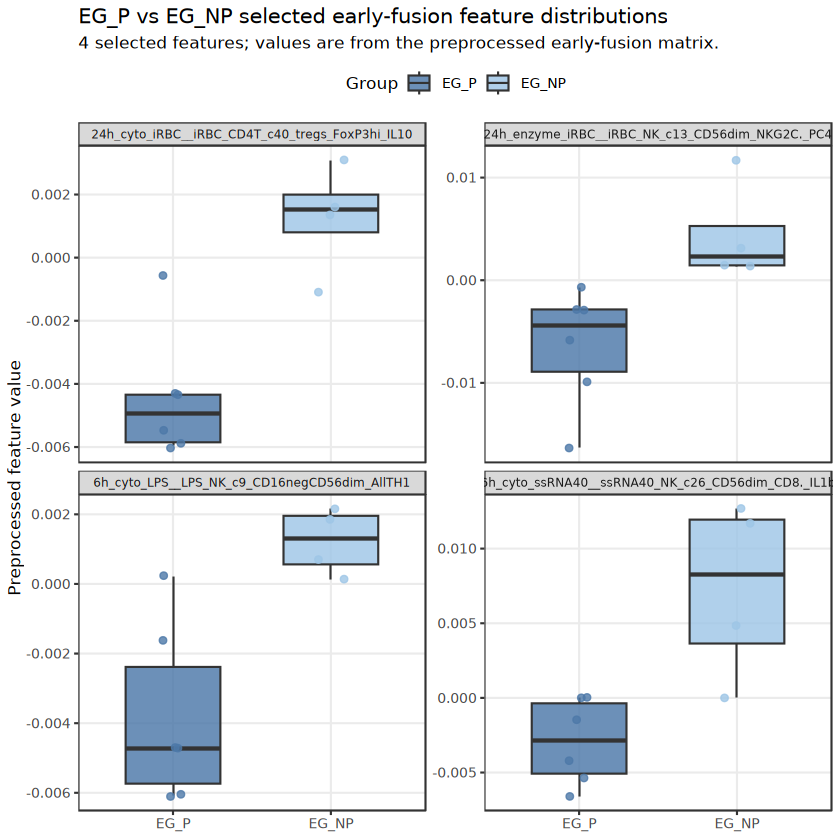

In [10]:
eg_selected_feature_boxplots <- plot_within_selected_feature_boxplots("EG")
eg_selected_feature_boxplots$selected_features
eg_selected_feature_boxplots$plot


### TU_P vs TU_NP


comparison,outcome_level,feature,stability_score,selected,view,feature_name
<chr>,<chr>,<chr>,<dbl>,<lgl>,<chr>,<chr>
TU_P_vs_TU_NP,global,24h_cyto_SEB__SEB_NK_c23_ILC_AnyTH1,1.000,TRUE,24h_cyto_SEB,SEB_NK_c23_ILC_AnyTH1
TU_P_vs_TU_NP,global,24h_cyto_SEB__SEB_NK_c23_ILC_IFNg,1.000,TRUE,24h_cyto_SEB,SEB_NK_c23_ILC_IFNg
TU_P_vs_TU_NP,global,6h_cyto_ssRNA40__ssRNA40_NK_c4_Other_CD7._IL6,1.000,TRUE,6h_cyto_ssRNA40,ssRNA40_NK_c4_Other_CD7._IL6
TU_P_vs_TU_NP,global,24h_cyto_SEB__SEB_NK_c23_ILC_IL2,0.996,TRUE,24h_cyto_SEB,SEB_NK_c23_ILC_IL2
TU_P_vs_TU_NP,global,24h_cyto_SEB__SEB_NK_c23_ILC_IL10,0.950,TRUE,24h_cyto_SEB,SEB_NK_c23_ILC_IL10
TU_P_vs_TU_NP,global,24h_cyto_SEB__SEB_NK_c23_ILC_TNF,0.936,TRUE,24h_cyto_SEB,SEB_NK_c23_ILC_TNF
TU_P_vs_TU_NP,global,3d_cyto__X3D_CD8T_c32_CXCR5.CCR7._IL2,0.928,TRUE,3d_cyto,X3D_CD8T_c32_CXCR5.CCR7._IL2
TU_P_vs_TU_NP,global,3d_cyto__X3D_CD8T_c32_CXCR5.CCR7._AllTH1,0.882,TRUE,3d_cyto,X3D_CD8T_c32_CXCR5.CCR7._AllTH1
TU_P_vs_TU_NP,global,3d_cyto__X3D_DNT_c25_CXCR5.CCR7._IL2,0.838,TRUE,3d_cyto,X3D_DNT_c25_CXCR5.CCR7._IL2


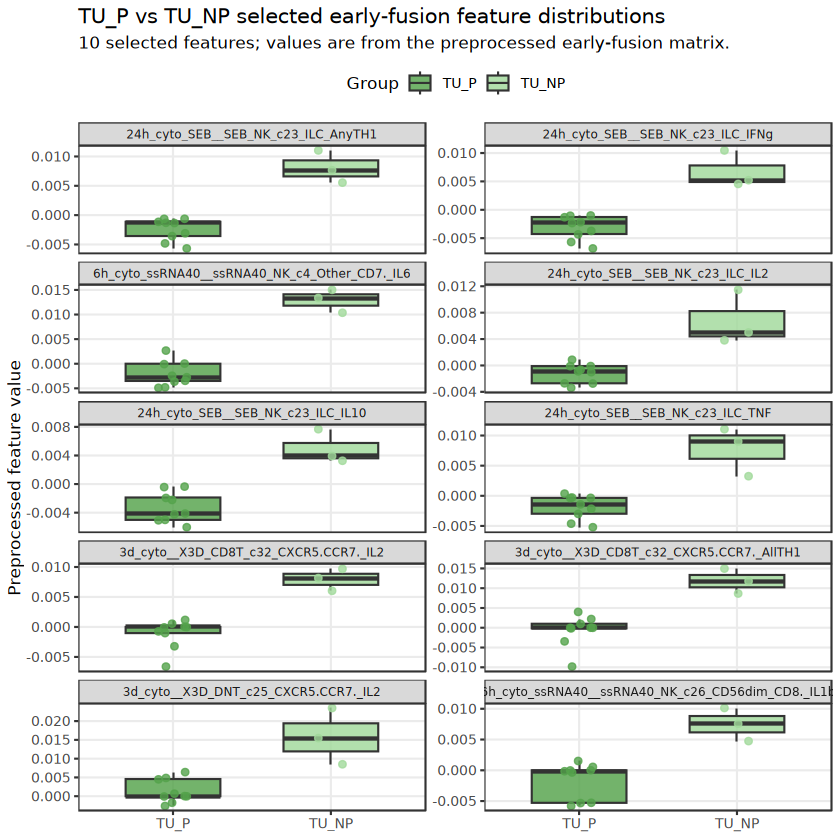

In [11]:
tu_selected_feature_boxplots <- plot_within_selected_feature_boxplots("TU")
tu_selected_feature_boxplots$selected_features
tu_selected_feature_boxplots$plot


### GA_P vs GA_NP


comparison,outcome_level,feature,stability_score,selected,view,feature_name
<chr>,<chr>,<chr>,<dbl>,<lgl>,<chr>,<chr>
GA_P_vs_GA_NP,global,cytof_celltype__clr_10,1.000,TRUE,cytof_celltype,clr_10
GA_P_vs_GA_NP,global,24h_enzyme_iRBC__iRBC_DNT_c14_FoxP3._PC3,0.998,TRUE,24h_enzyme_iRBC,iRBC_DNT_c14_FoxP3._PC3
GA_P_vs_GA_NP,global,24h_cyto_iRBC__iRBC_gdT_c22_vd1_IFNg,0.952,TRUE,24h_cyto_iRBC,iRBC_gdT_c22_vd1_IFNg


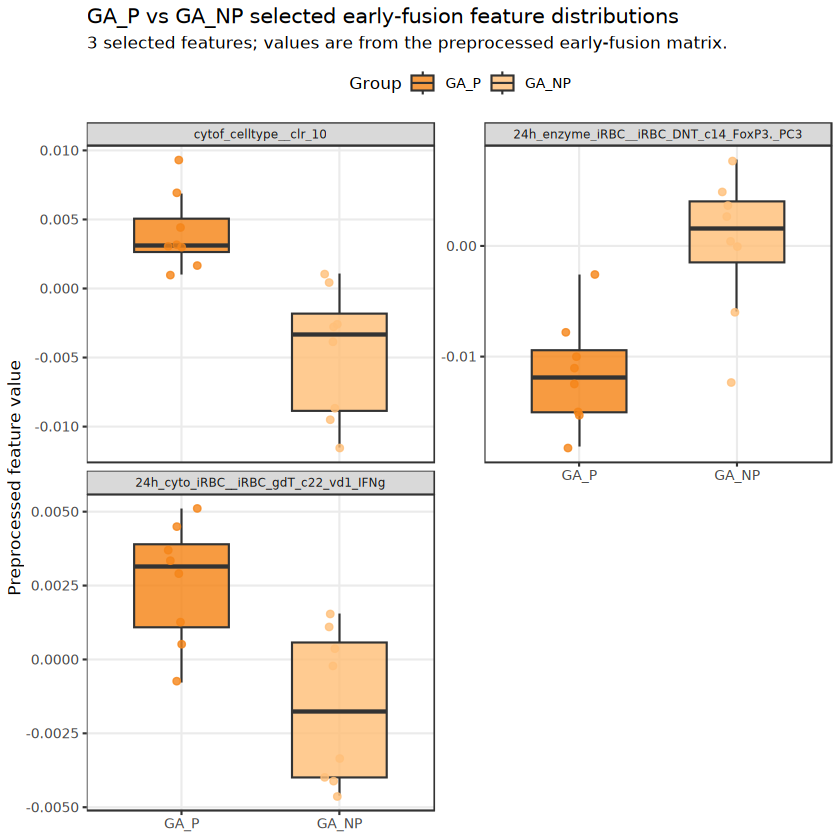

In [12]:
ga_selected_feature_boxplots <- plot_within_selected_feature_boxplots("GA")
ga_selected_feature_boxplots$selected_features
ga_selected_feature_boxplots$plot


In [13]:
# Within-study late fusion -----------------------------------------------------
within_late_fusion <- purrr::set_names(lapply(STUDY_LEVELS, function(study) {
  branch <- file.path("within", study, "late_fusion")
  if (!file.exists(branch_cache_path(branch, "late_fusion_result"))) {
    maybe_run_branch(paste("within", study, "late_fusion", sep = ":"))
  }
  load_late_fusion_bundle(branch)
}), STUDY_LEVELS)

within_late_metrics <- purrr::map_dfr(within_late_fusion, "metrics")
within_late_per_outcome_metrics <- purrr::map_dfr(within_late_fusion, "per_outcome_metrics")
within_late_confusion <- purrr::map_dfr(within_late_fusion, "confusion")
within_late_weights <- purrr::map_dfr(within_late_fusion, "weights")

within_late_metrics
within_late_per_outcome_metrics
within_late_confusion
within_late_weights

comparison,outcome_level,metric,value
<chr>,<chr>,<chr>,<dbl>
EG_P_vs_EG_NP,global,accuracy,1
EG_P_vs_EG_NP,global,balanced_error_rate,0
EG_P_vs_EG_NP,global,macro_f1,1
EG_P_vs_EG_NP,global,late_fusion_score,1
TU_P_vs_TU_NP,global,accuracy,1
TU_P_vs_TU_NP,global,balanced_error_rate,0
TU_P_vs_TU_NP,global,macro_f1,1
TU_P_vs_TU_NP,global,late_fusion_score,1
GA_P_vs_GA_NP,global,accuracy,1


comparison,outcome_level,support,predicted,recall,precision,f1
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
EG_P_vs_EG_NP,P,6,6,1,1,1
EG_P_vs_EG_NP,NP,4,4,1,1,1
TU_P_vs_TU_NP,P,9,9,1,1,1
TU_P_vs_TU_NP,NP,3,3,1,1,1
GA_P_vs_GA_NP,P,8,8,1,1,1
GA_P_vs_GA_NP,NP,8,8,1,1,1


comparison,outcome_level,truth,predicted,Freq
<chr>,<chr>,<chr>,<chr>,<dbl>
EG_P_vs_EG_NP,P,P,P,6
EG_P_vs_EG_NP,NP,NP,P,0
EG_P_vs_EG_NP,P,P,NP,0
EG_P_vs_EG_NP,NP,NP,NP,4
TU_P_vs_TU_NP,P,P,P,9
TU_P_vs_TU_NP,NP,NP,P,0
TU_P_vs_TU_NP,P,P,NP,0
TU_P_vs_TU_NP,NP,NP,NP,3
GA_P_vs_GA_NP,P,P,P,8


comparison,outcome_level,view,Associated_weight
<chr>,<chr>,<chr>,<dbl>
EG_P_vs_EG_NP,global,3d_enzyme,9.629882053
EG_P_vs_EG_NP,global,24h_enzyme_iRBC,9.063709483
EG_P_vs_EG_NP,global,exvivo_enzyme,8.895881826
EG_P_vs_EG_NP,global,3d_cyto,8.443333053
EG_P_vs_EG_NP,global,24h_cyto_SEB,7.419174009
EG_P_vs_EG_NP,global,6h_cyto_LPS,6.403086092
EG_P_vs_EG_NP,global,6h_cyto_ssRNA40,5.809245841
EG_P_vs_EG_NP,global,24h_enzyme_SEB,5.652400437
EG_P_vs_EG_NP,global,cytof_celltype,5.634285661


## SLURM Entrypoints

Use the preprocess job first, then the branch array. Individual branches can also be run by exporting `STABLR_BRANCH` or calling the runner directly.

In [14]:
# Commands --------------------------------------------------------------------
cat(
  "sbatch scratch/slurm/stablr_baseline_group_protection_preprocess.slurm\n",
  "sbatch scratch/slurm/stablr_baseline_group_protection_branches.slurm\n",
  "conda run -n R4_51 Rscript scratch/scripts/run_stablr_baseline_group_protection_branch.R joint:early_fusion\n",
  "conda run -n R4_51 Rscript scratch/scripts/run_stablr_baseline_group_protection_branch.R within:TU:single_view:cytof_celltype\n",
  sep = ""
)

sbatch scratch/slurm/stablr_baseline_group_protection_preprocess.slurm
sbatch scratch/slurm/stablr_baseline_group_protection_branches.slurm
conda run -n R4_51 Rscript scratch/scripts/run_stablr_baseline_group_protection_branch.R joint:early_fusion
conda run -n R4_51 Rscript scratch/scripts/run_stablr_baseline_group_protection_branch.R within:TU:single_view:cytof_celltype


## Notes

The within-study comparisons are intentionally focused on binary P-vs-NP fits within `EG`, `TU`, and `GA`. Cooperative OVR and nested CV are not included here because this notebook is scoped to cache-backed single-view, early-fusion, and late-fusion branches for small baseline strata.